---
tags: [tutorial]
---

# Controlling Gates and Sub-Kernels with `qmc.control`

`qmc.control` turns any Qamomile gate (a built-in like `qmc.rx`,
or a user-defined `@qmc.qkernel`) into its *controlled* version.

`qmc.control` has two modes: *concrete* (the number of control
qubits is a Python `int`) and *symbolic* (the number is a
`qmc.UInt` kernel parameter, or an expression that contains one,
resolved at transpile time). Most features — `power=`, default
args, sub-kernels that take `Vector[Qubit]`, reordering classical
kwargs — work the same way in both modes. What differs between
the modes is how the control arguments are passed and a small
set of mode-specific extras, handled in later sections.

In [1]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.circuit.transpiler.errors import EmitError, UnreturnedBorrowError
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

(cg-1)=
## 1. The minimal example: controlled-RX

The simplest, most practical use of `qmc.control` is to make a
controlled version of one of the gates Qamomile provides. For
example, below we pass the one-qubit gate `qmc.rx(q, angle)` to
`qmc.control` to obtain a two-qubit controlled-RX gate.

In [3]:
# Define the controlled-RX gate.
crx = qmc.control(qmc.rx)

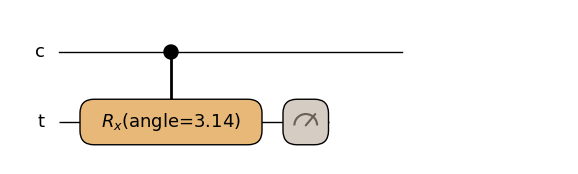

In [4]:
@qmc.qkernel
def crx_control_off() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # The control stays |0>, so the controlled rotation does NOT fire.
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_control_off.draw()

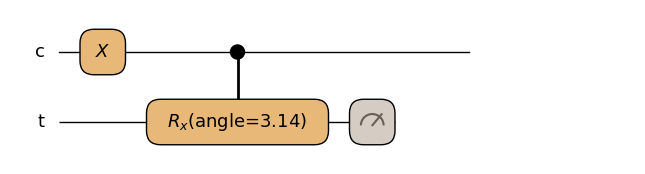

In [5]:
@qmc.qkernel
def crx_control_on() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # Drive the control to |1>, so the controlled rotation fires.
    c = qmc.x(c)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_control_on.draw()

To confirm the control actually takes effect, we transpile both
kernels to Qiskit, run them on the simulator, and check the
target measurement. With `angle=math.pi`, `RX(pi)` maps |0> to
|1>, so the target ends up |1> on every shot when the control is
|1>, and stays |0> otherwise.

In [6]:
off_counts = dict(
    transpiler.transpile(crx_control_off)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
on_counts = dict(
    transpiler.transpile(crx_control_on)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
print("control |0> ->", off_counts)
assert off_counts == {0: 256}
print("control |1> ->", on_counts)
assert on_counts == {1: 256}

control |0> -> {0: 256}
control |1> -> {1: 256}


A few points to note:

- You can write `crx = qmc.control(qmc.rx)` either inside or
  outside a qkernel. Either way the returned value is reusable;
  bind it to a name and call it as many times as you like.
- When you call `crx(c, t, angle=...)`, the control qubits come
  first as positional arguments, then the targets, then any
  classical keyword arguments. The order mirrors the
  `qmc.rx(q, angle)` signature of the gate being controlled,
  with a control prefixed.
- The keyword name for the classical parameter is whatever the
  controlled gate uses (`angle` for `qmc.rx`, `theta` for
  `qmc.p`, etc.) — `qmc.control` does not rename it.

(cg-2)=
## 2. Two modes at a glance

`qmc.control` has two modes. Which one you are in is decided
entirely by the type you pass for `num_controls`: a Python
`int` puts you in *concrete* mode, a `qmc.UInt` handle (or any
`UInt` expression like `n - 1`) puts you in *symbolic* mode.
Everything else about the call follows from that choice.

| Aspect | Concrete | Symbolic |
| --- | --- | --- |
| `num_controls=` | Python `int` (default `1`) | `qmc.UInt` handle, or any `UInt` expression |
| Control argument(s) | one or more positional args (`Qubit`, `VectorView`, or `Vector[Qubit]`) whose qubit counts sum to `num_controls` | one positional `Vector[Qubit]` / `VectorView` *pool* (single-pool form, with optional `control_indices`), **or** several positional args mixing `Qubit` / `VectorView` / `Vector[Qubit]` |
| `control_indices` | not accepted | optional — picks which slots of the pool are active |
| Control count resolved at | when `qmc.control(...)` is evaluated (module-load or tracing time) | transpile time (from `bindings`) |

Most of `qmc.control`'s features (`power=`, default values,
classical-kwarg reordering, sub-kernels that take
`Vector[Qubit]`, the multi-argument control shapes, ...) behave
identically in both modes; [](#cg-3) collects those. [](#cg-4)
covers the one shape that genuinely requires concrete mode, and
[](#cg-5) the symbolic-mode-specific features.

(cg-3)=
## 3. Patterns that work in BOTH modes

Each feature in this section behaves the same way in either mode.
The cells below use concrete mode for brevity, but the same
feature is available in symbolic mode too — the only differences
are that `num_controls` is a `UInt` expression and the
qubit-count match is checked at transpile time. [](#cg-5) covers
the symbolic-only argument shapes.

(cg-3-1)=
### 3.1 Controlling any callable

`qmc.control` accepts either a built-in gate function (`qmc.rx`,
`qmc.h`, `qmc.p`, ...) or any user-defined `@qmc.qkernel`. The
example below uses two controlled operations in one kernel: `ch`
(the controlled `qmc.h`) and `cg` (the controlled user-defined
`_h_then_rx`).

In [7]:
@qmc.qkernel
def _h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


ch = qmc.control(qmc.h)
cg = qmc.control(_h_then_rx)

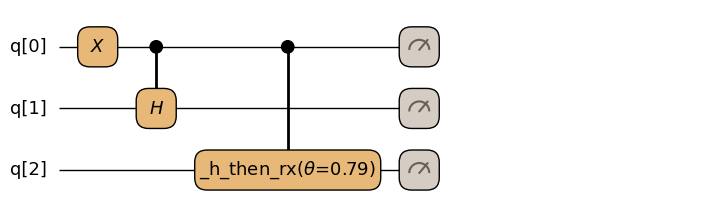

In [8]:
@qmc.qkernel
def control_any_callable_demo() -> qmc.Vector[qmc.Bit]:
    # q[0] is the shared control; q[1] / q[2] are the two targets.
    q = qmc.qubit_array(3, "q")
    q[0] = qmc.x(q[0])
    q[0], q[1] = ch(q[0], q[1])
    q[0], q[2] = cg(q[0], q[2], theta=math.pi / 4)
    return qmc.measure(q)


control_any_callable_demo.draw()

(cg-3-2)=
### 3.2 Sub-kernel taking `Vector[Qubit]`

A controlled kernel may take a `Vector[Qubit]` argument. The
caller passes a `Vector` or a `VectorView` of the matching
length.

In [9]:
@qmc.qkernel
def _vec_h(qs: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    qs[0] = qmc.h(qs[0])
    qs[1] = qmc.h(qs[1])
    return qs


cg = qmc.control(_vec_h, num_controls=1)

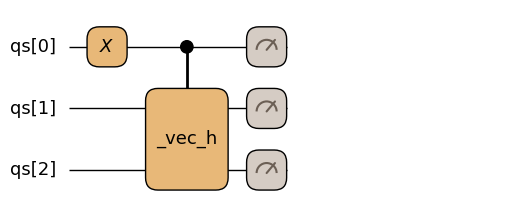

In [10]:
@qmc.qkernel
def vec_target_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(3, "qs")
    qs[0] = qmc.x(qs[0])
    qs[0], qs[1:3] = cg(qs[0], qs[1:3])
    return qmc.measure(qs)


vec_target_demo.draw()

(cg-3-3)=
### 3.3 Default values from the controlled kernel's signature

When the controlled kernel declares a Python default for a
classical parameter, the caller may omit that keyword.

In [11]:
@qmc.qkernel
def _phase(
    q: qmc.Qubit,
    # Runtime: ``_create_bound_input`` accepts a raw ``float`` default for
    # a ``qmc.Float`` parameter and wraps it as a constant ``Float`` handle.
    # Static signature: declares the actual handle type; ``# type: ignore``
    # acknowledges that the default literal is intentionally not a ``Float``
    # instance.
    theta: qmc.Float = math.pi / 2,  # type: ignore[assignment]
) -> qmc.Qubit:
    return qmc.rx(q, theta)


cg = qmc.control(_phase)

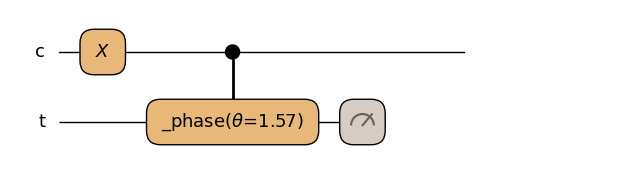

In [12]:
@qmc.qkernel
def default_arg_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    c, t = cg(c, t)  # theta defaults to math.pi / 2
    return qmc.measure(t)


default_arg_demo.draw()

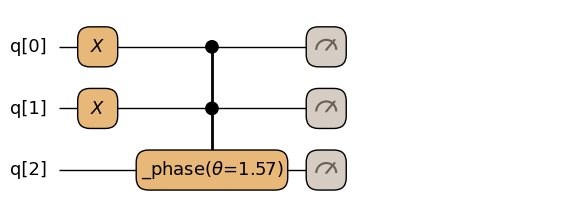

In [13]:
# Same `_phase` kernel, this time controlled with a symbolic
# `num_controls=n - 1`.  The `theta=math.pi / 2` default still
# applies even though the caller never names it.  Replace the
# omitted `theta` with a positional override at the call site
# (`cg(q[0 : n - 1], q[n - 1], math.pi / 4)`) when you want a
# different angle without switching to a kwarg.
@qmc.qkernel
def default_arg_demo_symbolic(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q[0 : n - 1] = qmc.x(q[0 : n - 1])  # drive every control slot to |1>
    cg = qmc.control(_phase, num_controls=n - 1)  # symbolic num_controls
    q[0 : n - 1], q[n - 1] = cg(q[0 : n - 1], q[n - 1])
    return qmc.measure(q)


default_arg_demo_symbolic.draw(n=3, fold_loops=False)

(cg-3-4)=
### 3.4 Controlling `U^k` with `power=`

Passing `power=k` controls the *k-th power* `U^k` instead of `U`
itself. `power` accepts a Python `int` (resolved at compile
time) or a `qmc.UInt` handle (resolved at transpile time from
`bindings`), and works regardless of whether `num_controls` is
concrete or symbolic.

In [14]:
cg = qmc.control(qmc.rx)  # num_controls = 1 (concrete)

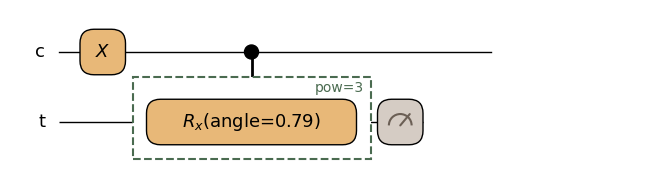

In [15]:
@qmc.qkernel
def power_demo_concrete() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    c, t = cg(c, t, angle=math.pi / 4, power=3)  # power is a Python int
    return qmc.measure(t)


power_demo_concrete.draw()

(cg-3-5)=
### 3.5 Multiple separate positional control args (CCX style)

With `num_controls=2`, the call site lists each control qubit
as its own positional argument before the target. The example
below is the canonical CCX (Toffoli): two controls `c0`, `c1`
and a target `t`. The same pattern extends to `num_controls=3`
(CCCX), `num_controls=4`, etc., as long as you have that many
distinct `Qubit` handles to pass in.

In [16]:
ccx = qmc.control(qmc.x, num_controls=2)

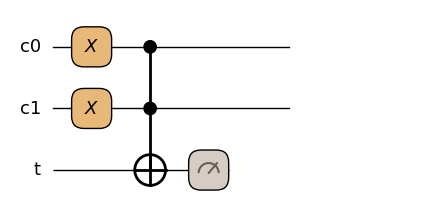

In [17]:
@qmc.qkernel
def toffoli_demo() -> qmc.Bit:
    c0 = qmc.qubit(name="c0")
    c1 = qmc.qubit(name="c1")
    t = qmc.qubit(name="t")
    c0 = qmc.x(c0)
    c1 = qmc.x(c1)
    c0, c1, t = ccx(c0, c1, t)
    return qmc.measure(t)


toffoli_demo.draw()

(cg-3-6)=
### 3.6 Mixing scalar Qubit and `VectorView` controls

The positional control prefix may freely mix scalar `Qubit`
handles, `VectorView` slices, and whole `Vector[Qubit]`s, as
long as the total qubit count adds up to `num_controls`. Here
the three controls for a `num_controls=3` controlled-H come from
`qs[0]` (a scalar `Qubit`, 1 qubit) plus `qs[1:3]` (a
`VectorView`, 2 qubits).

In [18]:
cg = qmc.control(qmc.h, num_controls=3)

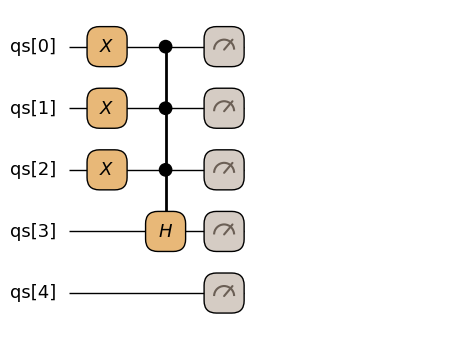

In [19]:
@qmc.qkernel
def mixed_controls_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(5, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    qs[0], qs[1:3], qs[3] = cg(qs[0], qs[1:3], qs[3])
    return qmc.measure(qs)


mixed_controls_demo.draw()

(cg-4)=
## 4. Concrete-mode-only: a single scalar control

Almost every control-argument shape works in both modes
([](#cg-3)), and symbolic mode adds its own features
([](#cg-5)). The one shape that genuinely *requires* concrete
mode is a single scalar `Qubit` as the lone control. In symbolic
mode a single control argument is read as the pool form and must
be a `Vector` / `VectorView`; a control whose count is fixed at
one has no reason to be symbolic anyway. This is exactly the
minimal controlled-RX of [](#cg-1); the controlled-X (CNOT)
below is the same single-scalar-control shape.

In [20]:
cx = qmc.control(qmc.x)  # num_controls defaults to 1 (concrete)

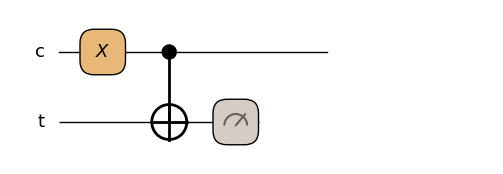

In [21]:
@qmc.qkernel
def cnot_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)  # drive the control to |1> so the X fires
    c, t = cx(c, t)
    return qmc.measure(t)


cnot_demo.draw()

(cg-5)=
## 5. Symbolic-mode patterns

This section covers what you get when `num_controls` is a
`qmc.UInt` handle (or any `UInt` expression like `n - 1`): the
number of *active* controls is decided at transpile time from
`bindings`, not at the moment `qmc.control(..., num_controls=...)`
is evaluated. [](#cg-5-5) also shows the symbolic counterpart of
[](#cg-3-5) / [](#cg-3-6).

Two call-site shapes are supported for the control side:

- **Single-pool form** ([](#cg-5-1) – [](#cg-5-4)): one
  `Vector[Qubit]` or `VectorView` is passed as the control
  argument, and the entire pool — or the subset chosen by
  `control_indices` — acts as the active controls.
- **Multi-arg form** ([](#cg-5-5)): the control prefix is several
  positional arguments (scalar `Qubit`, `VectorView`,
  `Vector[Qubit]`, or a mix) whose qubit counts sum to
  `num_controls`. This is what concrete mode already does
  ([](#cg-3-5) / [](#cg-3-6)), lifted to a symbolic
  `num_controls`.

The `control_indices` keyword is symbolic-mode only; it picks
which slots of a single-pool argument wire in as active controls
(the rest pass through untouched). `control_indices` is valid
only with the single-pool form; combining it with the multi-arg
form is rejected.

(cg-5-1)=
### 5.1 `num_controls = n` over a whole pool

The simplest symbolic shape: `num_controls=n` with the entire
pool (length `n`) used as the active controls. The parameter `n`
is made concrete at transpile time via `bindings`.

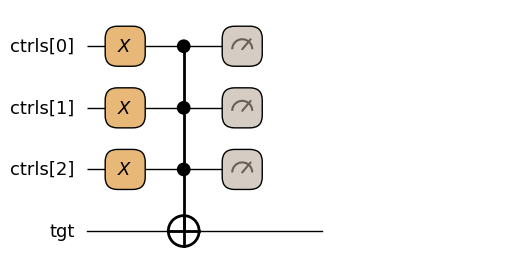

In [22]:
@qmc.qkernel
def symbolic_pool(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    ctrls = qmc.qubit_array(n, "ctrls")
    tgt = qmc.qubit(name="tgt")
    ctrls = qmc.x(ctrls)  # drive all controls to |1>
    cg = qmc.control(qmc.x, num_controls=n)  # symbolic n as the control count
    ctrls, tgt = cg(ctrls, tgt)
    return qmc.measure(ctrls)


symbolic_pool.draw(n=3, fold_loops=False)

(cg-5-2)=
### 5.2 Canonical `n - 1` multi-controlled form

A frequent shape in multi-controlled-X designs: the first
`n - 1` qubits of a register become controls, the last one
becomes the target. The bound on `num_controls` is the symbolic
expression `n - 1`, and the control argument is the slice
`qs[0:n - 1]`.

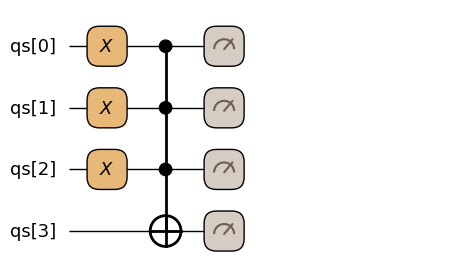

In [23]:
@qmc.qkernel
def mcx_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(n, "qs")
    qs[0 : n - 1] = qmc.x(qs[0 : n - 1])  # drive the control part to |1>
    mcx = qmc.control(qmc.x, num_controls=n - 1)
    qs[0 : n - 1], qs[n - 1] = mcx(qs[0 : n - 1], qs[n - 1])
    return qmc.measure(qs)


mcx_demo.draw(n=4, fold_loops=False)

(cg-5-3)=
### 5.3 Selecting a subset with `control_indices`

When the control pool is wider than the number of active
controls you want, the `control_indices` keyword (symbolic mode
only) picks which pool slots are wired in. The remaining slots
are left untouched. The indices do not have to be contiguous.

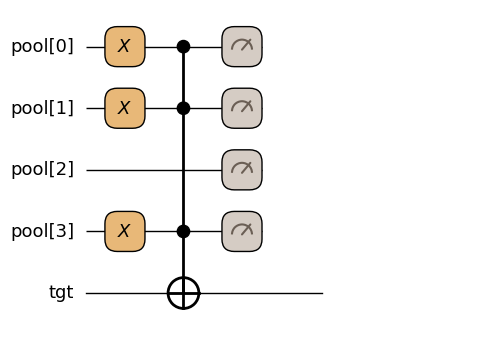

In [24]:
@qmc.qkernel
def subset_pool(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])  # pool[2] left at |0> — it is the inactive slot
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, control_indices=[0, 1, 3])
    return qmc.measure(pool)


subset_pool.draw(n=4, k_ctrls=3)

(cg-5-4)=
### 5.4 `control_indices` with `UInt` entries

Each entry inside `control_indices` may be a Python `int`
literal, a `qmc.UInt` handle, or any arithmetic expression over
`UInt` values. Cheap structural checks on literal `int` entries
(rejecting `bool`, negative values, and entries that duplicate
another literal `int` in the list) are done at compose time;
everything else — length agreement with `num_controls`, range
against the pool size, and any check that depends on a `UInt`
resolving to a concrete value — is deferred to transpile time
once `bindings` make the parameters concrete.

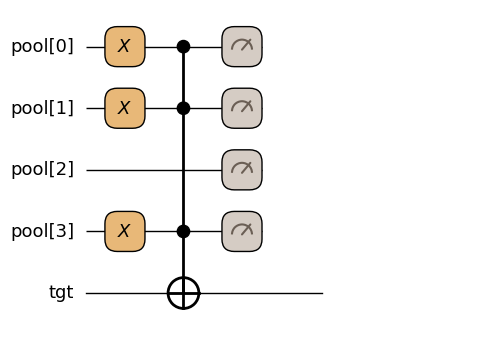

In [25]:
@qmc.qkernel
def subset_pool_with_uint(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, control_indices=[0, 1, n - 1])
    return qmc.measure(pool)


subset_pool_with_uint.draw(n=4, k_ctrls=3)

(cg-5-5)=
### 5.5 Multi-arg control prefix

When you want to split the controls across several positional
arguments — typically because you want some slots of a single
`Vector` to be active controls and another slot to be the
target — symbolic mode accepts the same multi-arg shape concrete
mode does ([](#cg-3-5) / [](#cg-3-6)). Several slots taken from
the same `Vector[Qubit]` may sit in the control prefix as long
as they are disjoint (non-overlapping). The qubit counts of the
control-prefix args are matched against `num_controls` at
transpile time.

Note that `control_indices` cannot be used with the multi-arg
form (see the reject case in [](#cg-6)). If you need subset
selection, use the single-pool form ([](#cg-5-3) / [](#cg-5-4));
if you need the multi-arg flexibility, treat the whole prefix as
active.

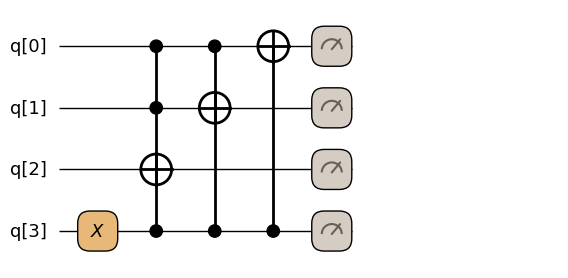

In [26]:
@qmc.qkernel
def controlled_increment_demo(
    n: qmc.UInt, control_index: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q[control_index] = qmc.x(q[control_index])
    # ``q.shape[0]`` is typed as ``int | UInt``; rebinding ``n`` would
    # widen the parameter's narrow ``qmc.UInt`` annotation, so introduce
    # a fresh local instead.
    n_shape = q.shape[0]
    for k in qmc.range(n_shape - 1):
        target_idx = n - 2 - k
        ctrl_main = q[control_index]
        prefix = q[0:target_idx]
        tgt = q[target_idx]
        cg = qmc.control(qmc.x, num_controls=target_idx + 1)
        ctrl_main, prefix, tgt = cg(ctrl_main, prefix, tgt)
        q[control_index] = ctrl_main
        q[0:target_idx] = prefix
        q[target_idx] = tgt
    return qmc.measure(q)


controlled_increment_demo.draw(n=4, control_index=3, fold_loops=False)

(cg-6)=
## 6. Patterns that don't work

This section walks through the rejected call shapes one at a
time, asserting the expected exception with a small
`expect_error` helper.

| Case | Mode | Exception |
| --- | --- | --- |
| 6.1 control qubit count crosses an argument boundary | concrete | `ValueError` |
| 6.2 `control_indices` in concrete mode | concrete | `ValueError` |
| 6.3 symbolic-length `VectorView` in concrete | concrete | `NotImplementedError` |
| 6.4 same-pool slot reused as target | symbolic | `UnreturnedBorrowError` |
| 6.5 multi-arg control prefix + `control_indices` | symbolic | `ValueError` |
| 6.6 single scalar control in symbolic mode | symbolic | `ValueError` |
| 6.7 controlled QFT over a sub-kernel `UInt` slice | concrete | `EmitError` |

In [27]:
def expect_error(label: str, exc_type: type[BaseException], body) -> None:
    """Assert that ``body`` raises an exception of ``exc_type``.

    The helper only catches the *expected* exception class.  Any
    other exception propagates out untouched so a regression that
    swaps the exception type surfaces with a normal traceback in
    the cell.  Missing the exception entirely raises an
    ``AssertionError``.
    """
    try:
        body()
    except exc_type as exc:
        print(f"[{type(exc).__name__}] {label}: {exc}")
        return
    raise AssertionError(
        f"{label}: expected {exc_type.__name__}, but no exception was raised"
    )

(cg-6-1)=
### 6.1 Control qubit count crosses an argument boundary (concrete)

Concrete mode walks the positional arguments in order, folding
each one into the control list until the running total reaches
`num_controls`. If a `VectorView` or `Vector` pushes the running
total past `num_controls`, the call is rejected.

In [28]:
def case_count_mismatch() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        qs = qmc.qubit_array(6, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, t = cg(qs[0:5], qs[5])  # 5 qubits supplied, 3 expected
        qs[0:5] = view
        return qmc.measure(qs[5])

    _ = kernel.block


expect_error("control count mismatch", ValueError, case_count_mismatch)

[ValueError] control count mismatch: concrete num_controls=3: positional argument #0 would push the control qubit count from 0 to 5, crossing the control / sub-kernel boundary mid-argument.  Split the argument so the boundary falls between args.


(cg-6-2)=
### 6.2 `control_indices` in concrete mode (concrete)

`control_indices` only makes sense when there is a control
*pool* to select from, which is a symbolic-mode concept.
Supplying it alongside a concrete `num_controls` raises
`ValueError` at compose time.

In [29]:
def case_control_indices_in_concrete() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)  # num_controls defaults to 1 (concrete)
        c, t = cg(c, t, control_indices=[0])
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "control_indices in concrete mode",
    ValueError,
    case_control_indices_in_concrete,
)

[ValueError] control_indices in concrete mode: control_indices is only valid in symbolic mode (num_controls=UInt).  Got concrete num_controls; concrete-mode controls are positional and have no selection step (see design §1.1).


(cg-6-3)=
### 6.3 Symbolic-length `VectorView` in concrete mode (concrete)

Concrete mode must determine each control argument's qubit count
at compile time. A slice whose length depends on a `UInt` is not
supported in concrete mode and raises `NotImplementedError`.

In [30]:
def case_symbolic_view_in_concrete() -> None:
    @qmc.qkernel
    def kernel(m: qmc.UInt) -> qmc.Bit:
        qs = qmc.qubit_array(m, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, q_out = cg(qs[0:m], qs[m - 1])
        qs[0:m] = view
        qs[m - 1] = q_out
        return qmc.measure(qs[m - 1])

    _ = kernel.block


expect_error(
    "symbolic-length VectorView in concrete mode",
    NotImplementedError,
    case_symbolic_view_in_concrete,
)

[NotImplementedError] symbolic-length VectorView in concrete mode: concrete num_controls with a symbolic-length Vector / VectorView control is not yet implemented in the frontend (tracked under Step 2.b of the controlled-API redesign).


(cg-6-4)=
### 6.4 Same-pool slot reused as target — single-pool form (symbolic)

With the single-pool form (`cg(pool, ...)` combined with
`control_indices`), it is tempting to take one of the pool's
inactive slots and pass it as the target — e.g.
`cg(pool, pool[2], control_indices=[0, 1, 3])` so that `pool[2]`
becomes the target of the controlled-U. The call is rejected by
the linear-type borrow tracker: the pool is already consumed as
one argument while `pool[2]` is borrowed for another, which
surfaces as `UnreturnedBorrowError` at compose time.

Workarounds (preferred order):

1. **Multi-arg symbolic form ([](#cg-5-5)).** Pass each slot or
   sub-view as its own positional argument:
   `cg(pool[0], pool[1], pool[3], pool[2])` (or the slice/scalar
   mix the controlled-increment example uses). Each argument is a
   separate borrow from `pool`, the borrow tracker checks
   disjointness, and `num_controls` matches the qubit-count sum
   at transpile time.
2. **Concrete mode ([](#cg-3-6)).** If `num_controls` is a Python
   `int`, the same multi-arg shape works without any symbolic
   plumbing.

In [31]:
def case_pool_slot_as_target() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(n, "pool")
        cg = qmc.control(qmc.x, num_controls=k_ctrls)
        pool, q = cg(pool, pool[2], control_indices=[0, 1, 3])
        pool[2] = q
        return qmc.measure(pool)

    _ = kernel.block


expect_error(
    "same-pool slot reused as target",
    UnreturnedBorrowError,
    case_pool_slot_as_target,
)

[UnreturnedBorrowError] same-pool slot reused as target: Array 'pool' has unreturned borrowed elements.
Borrowed elements: pool[2]

Fix: Write back all borrowed elements before using the array:
  q = pool[i]
  q = qm.h(q)
  pool[i] = q  # Return the element


(cg-6-5)=
### 6.5 Multi-arg control prefix + `control_indices` (symbolic)

The two symbolic-mode features are mutually exclusive.
`control_indices` only makes sense over a single control pool
(one `Vector` argument); combining it with multiple positional
control args raises `ValueError` at compose time.

In [32]:
def case_multi_arg_with_control_indices() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n, "q")
        ctrl_main = q[0]
        prefix = q[1:k]
        tgt = q[k]
        cg = qmc.control(qmc.x, num_controls=k + 1)
        ctrl_main, prefix, tgt = cg(ctrl_main, prefix, tgt, control_indices=[0, 1, 2])
        q[0] = ctrl_main
        q[1:k] = prefix
        q[k] = tgt
        return qmc.measure(q)

    _ = kernel.block


expect_error(
    "multi-arg + control_indices",
    ValueError,
    case_multi_arg_with_control_indices,
)

[ValueError] multi-arg + control_indices: control_indices is only supported with a single Vector[Qubit] / VectorView[Qubit] control argument (the pool form).  Combining control_indices with multiple positional control args is not supported.


(cg-6-6)=
### 6.6 Single scalar control in symbolic mode (symbolic)

A single scalar `Qubit` control is the one shape that needs
concrete mode. In symbolic mode a lone control argument is read
as the single-pool form, which requires a `Vector` /
`VectorView`.

In [33]:
def case_single_scalar_control_symbolic() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt) -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.rx, num_controls=n)
        c, t = cg(c, t, angle=math.pi)
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "single scalar control in symbolic mode",
    ValueError,
    case_single_scalar_control_symbolic,
)

[ValueError] single scalar control in symbolic mode: When num_controls is symbolic (UInt), a single control argument must be a Vector[Qubit] / VectorView pool, not a scalar Qubit.  A single fixed scalar control has no symbolic meaning (the count is one), so use concrete mode instead -- e.g. qmc.control(gate) with the default num_controls=1.  To keep a scalar control in symbolic mode, pass it together with at least one more control argument (the multi-arg form).


(cg-6-7)=
### 6.7 Controlled QFT over a sub-kernel `UInt` slice (concrete)

A controlled sub-kernel may call `qmc.qft` / `qmc.iqft` on a
`Vector[Qubit]` argument whose size is known at the call site.
For example, `controlled_qft = qmc.control(apply_qft)` works
when `apply_qft(q)` applies QFT to all of `q`.

The narrower pattern below is still unsupported: the wrapped
sub-kernel receives a classical `UInt` argument and uses it to
form a `q[:m]` slice before calling QFT. The controlled-U emitter
does not yet lower that parameterized sliced composite block into
a backend gate, so transpilation raises `EmitError`.

Workaround: make the QFT/IQFT width come from the target vector's
concrete shape at the controlled call site. In practice, pass the
exact target view to a sub-kernel that applies QFT to the whole
vector argument, instead of passing a larger vector plus a separate
`UInt` slice length.

In [34]:
def case_controlled_qft_over_uint_slice() -> None:
    @qmc.qkernel
    def qft_prefix(q: qmc.Vector[qmc.Qubit], m: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
        prefix = q[:m]
        prefix = qmc.qft(prefix)
        q[:m] = prefix
        return q

    @qmc.qkernel
    def kernel(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n + 1, "q")
        q[0] = qmc.x(q[0])
        controlled_qft = qmc.control(qft_prefix)
        q[0], targets = controlled_qft(q[0], q[1 : n + 1], n)
        q[1 : n + 1] = targets
        return qmc.measure(q)

    transpiler.transpile(kernel, bindings={"n": 2})


expect_error(
    "controlled QFT over a sub-kernel UInt slice",
    EmitError,
    case_controlled_qft_over_uint_slice,
)

[EmitError] controlled QFT over a sub-kernel UInt slice: Cannot decompose controlled-U with multi-target inner block (target_indices=[1, 2], block has 0 gate op(s)) on this backend: the per-gate fallback only routes each inner op to ``target_indices[0]``, so any gate intended for ``target_indices[i > 0]`` would silently miscompile to slot 0.  Either run this kernel on a backend whose ``circuit_to_gate`` succeeds (Qiskit produces a native controlled custom gate), or rewrite the wrapped sub-kernel to take individual ``Qubit`` arguments and apply the control element-by-element at the call site.


(cg-7)=
## 7. Summary

`qmc.control(fn, num_controls=...)` makes a controlled version
of any Qamomile built-in gate or user-defined kernel. It has two
modes, decided by the type of `num_controls`: a Python `int`
gives *concrete* mode, and a `qmc.UInt` (or a `UInt` expression
like `n - 1`) gives *symbolic* mode.